In [2]:
import numpy as np
import matplotlib.pyplot as plt

Let us simulate from a Beta distribution with a,b. 

### Simulations from Beta and Dirichlet distributions

In [3]:
#Simulate from Beta(a, b)
a = .000002
#a = 0.5
b = .000002
#b = 0.5
#a = 7
#b = 7
beta_samples = np.random.beta(a, b, size=1000)
print(beta_samples)
print(np.mean(beta_samples))


[0. 1. 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1.
 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1.
 1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1.
 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1.
 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1.
 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1.
 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 0.
 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1.
 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0.
 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1.
 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0.

By setting $a = b = \epsilon$ for some small $\epsilon$ in the above code, we can check that samples from $\text{Beta}(a, b)$ are 0 or 1 with equal frequency (up to Monte Carlo error). 

By setting $a = \epsilon$ and $b$ to be a fixed positive constant (e.g., $b = 0.5$), we get all samples equal to 0. 

Analogously, by setting $a$ to be a fixed positive constant (e.g., $a = 0$) and $b = \epsilon$, we get all samples equal to 1. 

Below we obtain samples from the Dirichlet distribution with $k = 4$. 

In [4]:
#Samples from Dirichlet distribution
k = 4
#alpha = np.array([0.02, 0.02, 0.02, 0.02])
#alpha = np.array([0.5, 0.5, 0.5, 0.0002])
alpha = np.array([3, 1, 0.000002, 0.000002])
dirichlet_samples = np.random.dirichlet(alpha, size=1000)
print(dirichlet_samples)
print(np.mean(dirichlet_samples, axis=0))

[[0.99177794 0.00822206 0.         0.        ]
 [0.27034347 0.72965653 0.         0.        ]
 [0.67852958 0.32147042 0.         0.        ]
 ...
 [0.58503574 0.41496426 0.         0.        ]
 [0.75436223 0.24563777 0.         0.        ]
 [0.92685921 0.07314079 0.         0.        ]]
[7.45880860e-001 2.54119100e-001 8.81217696e-104 3.97700492e-008]


If $a_1 = a_2 = a_3 = a_4 = \epsilon$ for some small $\epsilon$, then each Dirichlet sample will be one of $(1, 0, 0, 0)$, $(0, 1, 0, 0)$, $(0, 0, 1, 0)$, $(0, 0, 0, 1)$ with equal frequency (up to Monte Carlo error). 

If $a_1, a_2, a_3$ are some fixed numbers (not small) and $a_4 = \epsilon$ for a small $\epsilon$, then $p_4$ will be zero in every sample, and the other three $(p_1, p_2, p_3)$ are drawn from Dirichlet$(a_1, a_2, a_3)$. 

If $a_1, a_2$ are fixed numbers (not small) and $a_3 = a_4 = \epsilon$ for a small $\epsilon$, then $p_3, p_4$ will be zero in every sample, and the other two $(p_1, p_2)$ are drawn from Dirichlet$(a_1, a_2)$. 

## A simple problem to illustrate Dirichlet-Multinomial Inference

Consider the following problem that we already studied previously (see e.g., Lecture 4): 

*Suppose a scientist makes 6 numerical measurements $26.6, 38.5, 34.4, 34, 31, 23.6$ on an unknown real-valued physical quantity $\theta$. On the basis of these measurements, what can be inferred about $\theta$?*

Previously we solved this problem using the Bayesian model: 
\begin{align*}
   X_1, \dots, X_n \mid \theta,\sigma \overset{\text{i.i.d}}{\sim} N(\theta, \sigma^2)~~ \text{ and }~~ \theta, \log \sigma \overset{\text{i.i.d}}{\sim} \text{uniform}(-\infty, \infty). 
\end{align*}
This gave the following posterior for $\theta$: 
\begin{align*}
   \frac{\sqrt{n}(\theta - \hat{\theta})}{\sqrt{S(\hat{\theta})/(n-1)}} \mid \text{data} \sim t_{n-1}
\end{align*}
where $S(\theta) := \sum_{i=1}^n (x_i - \theta)^2$ and $\hat{\theta} = \bar{x} = (x_1 + \dots + x_n)/n$. This led to the 95% interval: $[25.598, 37.102]$. 

We now use the model: 
\begin{align*}
    X_1, \dots, X_n \mid P \overset{\text{i.i.d}}{\sim} P ~~ \text{ and } ~~ \theta = \text{mean corresponding to} ~ P
\end{align*}
We use discretization and assume that $P$ is supported on a large finite set $G = \{g_1, \dots, g_k\}$ e.g., $G = \{0.1, 0.2, \dots, 99.9, 100.0\}$. Let the probabilities assigned by $P$ to $g_1, \dots, g_k$ be $p_1, \dots, p_k$. We use the noninformative prior: 
\begin{align*}
   (p_1, \dots, p_k) \sim \text{Dirichlet}(0, \dots, 0). 
\end{align*}
This leads to the posterior: 
\begin{align*}
  P \mid X_1 = x_1, \dots, X_n = x_n \sim \sum_{i=1}^n w_i \delta_{\{x_i\}} ~\text{where} ~ (w_1, \dots, w_n) \sim \text{Dirichlet}(1, \dots, 1). 
\end{align*}
The posterior of $\theta$ is therefore: 
\begin{align*}
   \theta \mid \text{data} \sim \sum_{i=1}^n w_i x_i \text{ where } (w_1, \dots, w_n) \sim \text{Dirichlet}(1, \dots, 1). 
\end{align*}
Below we simulate from this posterior, and obtain posterior mean and 95\% credible interval.

In [5]:
x_obs = np.array([26.6, 38.5, 34.4, 34, 31, 23.6])
n = len(x_obs)
M = 100000 #number of posterior samples
np.random.seed(42) #for reproducibility
W = np.random.dirichlet(alpha = np.ones(n), size=M) #M samples from the Dirichlet distribution
theta_samples = W @ x_obs #compute the posterior samples of theta

theta_mean = np.mean(theta_samples)
theta_ci = np.quantile(theta_samples, [0.025, 0.975])

print(f"Posterior mean of theta: {theta_mean:.2f}")
print(f"95% credible interval: [{theta_ci[0]:.2f}, {theta_ci[1]:.2f}]")

Posterior mean of theta: 31.35
95% credible interval: [27.53, 34.90]


Below is a histogram of all the posterior samples. 

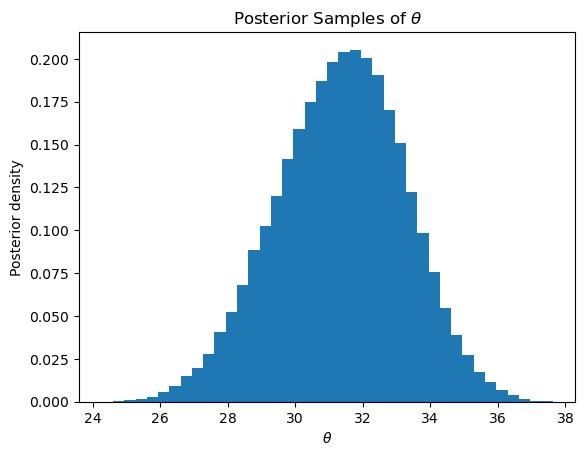

In [6]:
plt.hist(theta_samples, bins=40, density=True)
plt.xlabel(r"$\theta$")
plt.ylabel("Posterior density")
plt.title("Posterior Samples of $\\theta$")
plt.show()

This method is actually the Bayesian bootstrap because it is very close to the bootstrap operationally. 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, digamma

In [8]:
import numpy as np
import matplotlib.pyplot as plt

## How to simulate from the Dirichlet distribution?

Consider the Dirichlet distribution with parameters $a_1, \dots, a_k$. Let us assume that $a_1, \dots, a_k$ are all strictly positive. We will occasionally take some of the $a_j$-s to be small to mimic the effect of them being exactly zero. 

The Dirichlet distribution is a distribution on probability vectors $(p_1, \dots, p_k)$ (probability vector means that each $p_j \geq 0$ and $\sum_{j=1}^k p_j = 1$). In other words, if we simulate from the Dirichlet distribution, we obtain probability vectors. 

In [9]:
a = np.array([1, 2, 1])
k = len(a)
dir_samples = np.random.dirichlet(a, size = 5) 
print(dir_samples)
#each row of dir_samples is a probability vector of length k that sums to 1. We can verify this by summing across the rows:
print(np.sum(dir_samples, axis=1))

[[2.26286803e-03 7.30060200e-01 2.67676932e-01]
 [1.36337244e-01 4.64166503e-01 3.99496253e-01]
 [3.11908477e-01 6.16701084e-01 7.13904382e-02]
 [2.79625669e-01 6.61841626e-01 5.85327053e-02]
 [7.22311440e-04 8.94584761e-01 1.04692928e-01]]
[1. 1. 1. 1. 1.]


When $k = 3$, we can visualize probability vectors as points in the triangle with vertices $(1, 0, 0)$ (corresponding to $p_1 = 1$), $(0, 1, 0)$ (corresponding to $p_2 = 1$) and $(0, 0, 1)$ (corresponding to $p_3 = 1$). This is done below. 

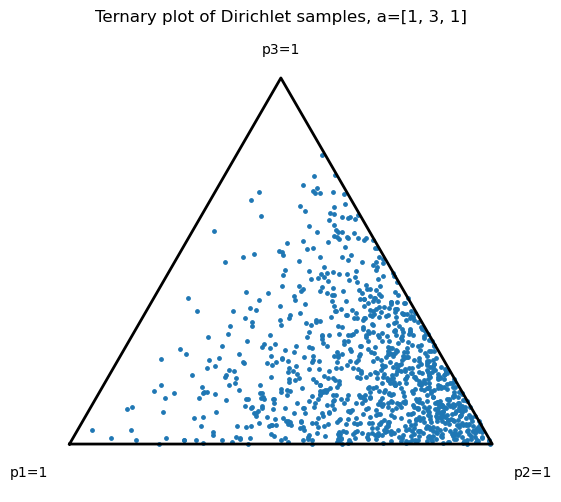

In [10]:
N = 1000
# a = np.array([0.0002, 0.0002, 0.0002])
# a = np.array([1, 1, 1])
a = np.array([1,3,1])
# a = np.array([0.00002, 1, 1])
P = np.random.dirichlet(a, size=N)  # shape (N,3)
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=6, alpha=1)

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "p1=1", ha="right", va="top")
plt.text( 1.05, -0.05, "p2=1", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "p3=1", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Dirichlet samples, a={a.tolist()}")
plt.show()

From the above plot (with varying $a_1, a_2, a_3$), the following observations can be made: 
1. When $a_i = 1$ for all $i$, the generated probability vector samples are uniformly distributed over the triangle (when $k \geq 3$ the triangle is referred to as the probability simplex). 
2. When $a_1 = 1 = a_3$ and $a_2 = 5$ is large, then the probability vectors are piled up near the corner corresponding to $p_2 = 1$. 
3. When $a_i = \epsilon$ for a small $\epsilon$ (e.g., $\epsilon = 0.0002$), the points are basically superimposed on the corners of the triangle. 
4. When $a_1 = \epsilon$ and $a_2 = a_3 = 1$, then $p_1$ will always be very nearly zero. So the points will be on the line joining the $p_2 = 1$ and $p_3 = 1$ corners. The probability vectors here can be seen as being supported only on the two coordinates $2$ and $3$. 

Now let us how exactly to simulate from the Dirichlet $(a_1, \dots, a_k)$ distribution (in other words, what is the code underlying numpy's np.random.dirichlet). One can use Gamma distributed random variables to obtain Dirichlet samples. We discuss this below. Let us first recall basic facts about Gamma distributions. Suppose $X_i \overset{\text{ind}}{\sim} \text{Gamma}(\text{shape} = a_i, \text{rate} = 1)$ for $i = 1, \dots, n$. Recall that the Gamma distribution with shape $a$ and rate $\lambda$ has the density: 
\begin{align*}
    x \mapsto \frac{\lambda^a}{\Gamma(a)} x^{a-1} \exp(-\lambda x) I\{x > 0\} ~~ \text{ where } ~~ \Gamma(a) := \int_0^{\infty} x^{a-1} e^{-x} dx. 
\end{align*}
We will only be using Gamma distributions with rate parameter set to 1 (i.e., $\lambda = 1$). In this case, the Gamma density becomes: 
\begin{align*}
   x \mapsto \frac{1}{\Gamma(a)} x^{a-1} e^{-x} I\{x > 0\}. 
\end{align*}
The simplest $\text{Gamma}(a, \lambda)$ density correspnds to $a = 1$ and it is the standard exponential density $\text{Gamma}(1, \lambda) = \text{Exp}(\lambda)$ with density function $\lambda \exp(-\lambda x) I\{x > 0\}$. In particular, $\text{Gamma}(1, 1)$ is $\text{Exp}(1)$ with density $\exp(-x) I\{x > 0\}$. 

Now we can state the connection between Dirichlet $(a_1, \dots, a_k)$ and Gamma random variables: 
\begin{align*}
 \left(\frac{X_1}{X_1 + \dots + X_k},  \dots, \frac{X_k}{X_1 + \dots + X_k} \right) \sim \text{Dirichlet}(a_1, \dots, a_k)
\end{align*}
provided
\begin{align*}
    X_i \overset{\text{ind}}{\sim} \text{Gamma}(a_i, 1). 
\end{align*}
In other words, to generate a probability vector from the Dirichlet $(a_1, \dots, a_k)$ distribution, we simply generate independent Gamma $(a_i, 1)$ distributed random variables, and then normalize them (by dividing each of them with their sum) to get a probability vector. 

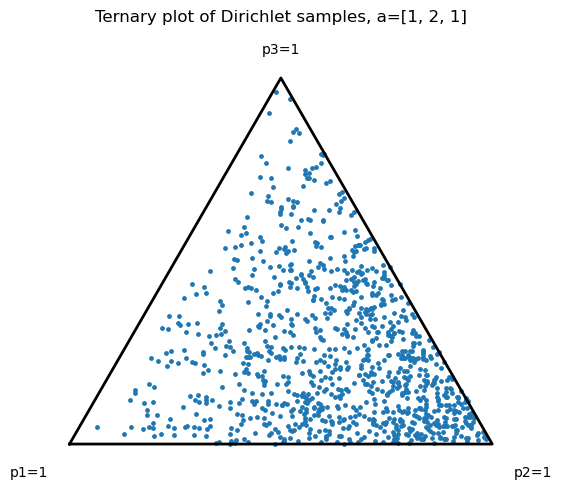

In [11]:
N = 1000
# a = np.array([0.0002, 0.0002, 0.0002])
# a = np.array([1, 1, 1])
#a = np.array([1, 5, 1])
#a = np.array([0.00002, 1, 1])
a = np.array([1, 2, 1])
k = len(a)
gamma_samples = np.random.gamma(shape=a, scale=1, size=(N, k))
P = gamma_samples / np.sum(gamma_samples, axis=1, keepdims=True)

#P = np.random.dirichlet(a, size=N)  # shape (N,3)
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=6, alpha=1)

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "p1=1", ha="right", va="top")
plt.text( 1.05, -0.05, "p2=1", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "p3=1", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Dirichlet samples, a={a.tolist()}")
plt.show()

## The Bayesian Bootstrap

### Coin Tossing


The Bayesian bootstrap can be understood with the following very simple example: Suppose a coin is tossed twice resulting in one head and one tail. What can then be said about the coin's probability $p$ of landing heads?

Bayesian inference with the prior $p \sim \text{Beta}(a, b)$ gives the answer: $p \mid \text{data} \sim \text{Beta}(a + 1, b + 1)$. This answer depends on $a$ and $b$. If we take $a = 0$ and $b = 0$, then we get the posterior $\text{Beta}(1, 1)$, which is same as the uniform distribution on $(0, 1)$. This means that (after seeing the data of 1 head and 1 tail), our uncertainty is spread equally among all the values of $p$. For example, $p \in (0.9, 1)$ has the same posterior probability as $p \in (0, 0.1)$ as well as $(0.45, 0.55)$. This wide uncertainty can be attributed to the fact that we have only observed the results of 2 coin tosses which resulted in 1 heads and 1 tails. If we get more data, then the posterior will get narrower. 

An interesting feature of the $\text{Beta}(0, 0)$ prior is the following. Suppose we only observe 1 coin toss which resulted in a heads. Then the posterior of $p$ is $\text{Beta}(1, 0)$ which is concentrated at 1. This means that we are fully confident that $p = 1$. 

This might appear quite peculiar because after 1 toss, we have a fully confident concentrated posterior, but after two tosses (which resulted in two different outcomes), we have a very flat posterior. 

Jaynes (Subsection 12.4.3) explains this phenomenon using the following analogy. Imagine ordering coffee at a cafe and looking for sugar. You see a jar containing a white granular substance. You taste a single granule and find it sweet. You then you immediately conclude all the granules in the jar are sweet. This corresponds to the $n = 1$ fully concentrated posterior above. But suppose you sample another granule and it turns out to be salty, then you are fully confused and have no idea how much proportion of granules in the jar are sweet and how much proportion are salty. Then your posterior on the proportion of sugar granules in the jar is the uniform distribution on $(0, 1)$.

It is important to specially note that the posterior after 1 head and 1 tail is not concentrated at the observed proportion $1/2$. Rather, it is fully diffuse and uniform over the entire interval $(0, 1)$. 

### Rolling dice

The same phenomenon applies in the Dirichlet case. Suppose we roll a six-faced die six times and observe each face exactly once. What then can we say about the probabilities $p_1, \dots, p_k$ ($k = 6$) associated with the six die faces? If our prior is $(p_1, \dots p_k) \sim \text{Dirichlet}(0, \dots, 0)$, then the posterior is $\text{Dirichlet}(1, \dots, 1)$. This means that we are fully uncertain about the probabilities and have assigned a uniform posterior for all probability vectors of length $6$. 

### Numerical Measurements

The same ideas can be applied more generally. Consider the following problem (simpler case of problem discussed in Lectures 12 and 13):  A scientist is repeatedly running an experiment which produced the observations $26.6, 38.5, 34.4$ in the first three runs. Based on these, what can we say about the probabilities with which the experiment produces various observations?

The idea is to treat this problem as the die rolling problem. In the die rolling problem, the total number of outcomes is 6. Now, we consider a much larger set of outcomes, say, $\{0, 0.1, 0.2, \dots, 99.8, 99.9, 100\}$ ($k$ is the size of this set). The experiment has been repeated three times resulting in the three distinct outcomes $26.6, 38.5, 34.4$. The goal is to estimate the probabilities $p_1, p_2, \dots, p_k$ where $p_i$ is the probability associated with the $i$-th outcome in the set $\{0, 0.1, 0.2, \dots, 99.8, 99.9, 100\}$.

The prior on $(p_1, \dots, p_k)$ is $\text{Dirichlet}(0, \dots, 0)$ and the posterior will be $\text{Dirichlet}(a_1, \dots, a_k)$ where $a_i$ equals zero for all $i$ except when the outcome is actually observed (in this case, $a_i$ will be 1). So the posterior is supported on probability vectors $(p_1, \dots, p_k)$ for which $p_i \neq 0$ only when $i$ is observed. So the posterior can be viewed as being supported on probability vectors on the three outcome space $\{26.6, 38.5, 34.4\}$. Further, the posterior is uniform on these three-outcome probability vectors: 
\begin{align*}
    \text{posterior}(p) = w_1 \delta_{\{26.6\}} + w_2 \delta_{\{38.5\}} + w_3 \delta_{\{34.4\}} ~~ \text{ with } (w_1, w_2, w_3) \sim \text{Dirichlet}(1, 1, 1). 
\end{align*}
This posterior refuses to consider any outcome that has not been actually been observed. However, on the observed outcomes, it is displaying maximal posterior uncertainty by allowing all weights with equal probability. 

The code below generates posterior samples. 

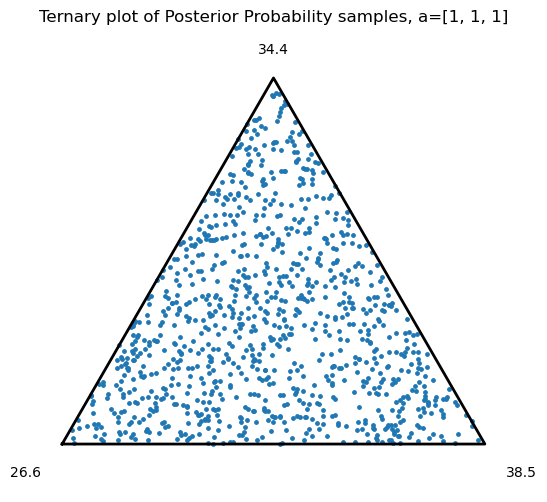

In [44]:
N = 1000
a = np.array([1, 1, 1])
k = len(a)
gamma_samples = np.random.gamma(shape=a, scale=1, size=(N, k))
P = gamma_samples / np.sum(gamma_samples, axis=1, keepdims=True)

#P = np.random.dirichlet(a, size=N)  # shape (N,3)
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=6, alpha=1)

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "26.6", ha="right", va="top")
plt.text( 1.05, -0.05, "38.5", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "34.4", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Posterior Probability samples, a={a.tolist()}")
plt.show()

The posterior samples are uniformly distributed over the entire probability triangle. 

### Comparison to classical bootstrap samples

In the classical bootstrap, one obtains re-samples by sampling with replacement from the observed data. 

In [45]:
bootstrap_samples = np.random.choice(np.array([26.6, 38.5, 34.4]), size=(10, 3), replace=True)
print(bootstrap_samples)

[[38.5 38.5 38.5]
 [34.4 26.6 34.4]
 [38.5 38.5 26.6]
 [34.4 38.5 26.6]
 [38.5 26.6 26.6]
 [34.4 38.5 34.4]
 [38.5 34.4 38.5]
 [34.4 26.6 38.5]
 [38.5 26.6 34.4]
 [38.5 38.5 34.4]]


Note that the order of numbers in each bootstrap sample is irrelevant. Each bootstrap sample contains a subset of the three observed numbers $26.6, 38.5, 34.4$. We can obtain an equivalent representation of the bootstrap samples by simply tracking the proportion of times 26.6 appears in the sample, the proportion of times 38.5 appears and the proportion of times 34.4 appears. For example, in this tracking scheme, the bootstrap sample $34.4, 34.4, 26.6$ becomes $1/3, 0, 2/3$. Note that these proportions (because they are nonnegative and sum to one) can also be viewed as probability vectors, so they can be plotted on the probability triangle. This is done below. 

In [46]:
N = 1000
bootstrap_samples = np.random.choice(np.array([26.6, 38.5, 34.4]), size=(N, 3), replace=True)
values = np.array([26.6, 38.5, 34.4])
proportion_samples = (bootstrap_samples[..., None] == values).mean(axis=1)
print(proportion_samples)

[[0.33333333 0.         0.66666667]
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 ...
 [0.         0.         1.        ]
 [0.66666667 0.33333333 0.        ]
 [0.33333333 0.33333333 0.33333333]]


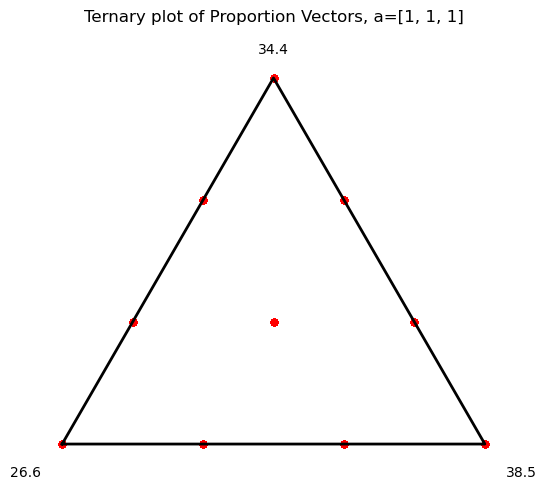

In [47]:
P = proportion_samples
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=20, alpha=1, color = 'red')

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "26.6", ha="right", va="top")
plt.text( 1.05, -0.05, "38.5", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "34.4", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Proportion Vectors, a={a.tolist()}")
plt.show()

Here we see the discrete nature of the classical bootstrap samples. The proportion vectors take only 10 distinct values (even though we generated $N = 1000$ of these proportion vectors). Below we plot both the Bayesian bootstrap posterior probability vectors and the classical bootstrap proportion vectors in the same plot. 

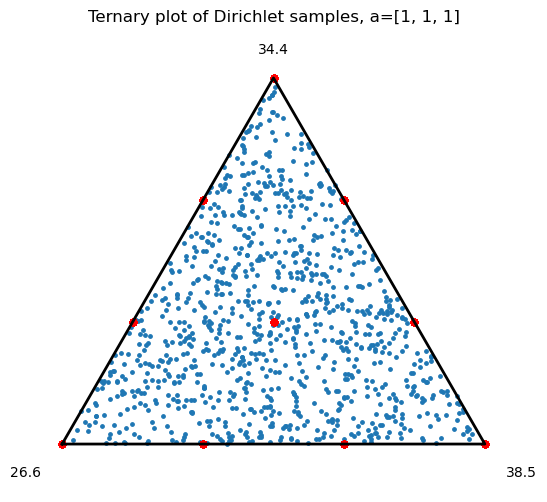

In [49]:
N = 1000
a = np.array([1, 1, 1])
k = len(a)
gamma_samples = np.random.gamma(shape=a, scale=1, size=(N, k))
P = gamma_samples / np.sum(gamma_samples, axis=1, keepdims=True)

#P = np.random.dirichlet(a, size=N)  # shape (N,3)
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=6, alpha=1)

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "26.6", ha="right", va="top")
plt.text( 1.05, -0.05, "38.5", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "34.4", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Dirichlet samples, a={a.tolist()}")

P = proportion_samples
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])


plt.scatter(x, y, s=20, alpha=1, color = 'red')

plt.show()

For classical bootstrap, we can generate the proportion vectors directly without actually resampling original data. This is because each proportion vector is itself distributed according to the following distribution: 
\begin{align*}
   (v_1, \dots, v_n) \sim \frac{1}{n}\text{Multinomial}(n; 1/n, \dots, 1/n). 
\end{align*}


In [17]:
prop_vectors = (np.random.multinomial(3, pvals=[1/3, 1/3, 1/3], size=N))/3
print(prop_vectors)

[[0.33333333 0.         0.66666667]
 [1.         0.         0.        ]
 [0.         0.33333333 0.66666667]
 ...
 [0.         0.66666667 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.         0.         1.        ]]


In practice, the goal in these kinds of problems is not to estimate the whole probability distribution of the experiment generating the observations, but instead, to estimate some parameter such as the mean or median $\theta$ of that probability distribution. In each of these methods (classical bootstrap or Bayesian bootstrap), posterior samples for $\theta$ are obtained by calculating the mean or mode for each bootstrap sample. 

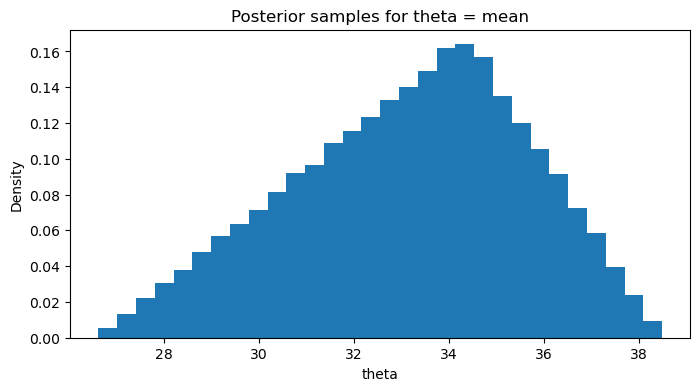

33.166666666666664 33.1691303883867


In [50]:
#Posterior samples for theta = mean
x_obs = np.array([26.6, 38.5, 34.4])
n = len(x_obs)
M = 100000
W = np.random.dirichlet(alpha=np.ones(n), size=M)
theta_samples = W @ x_obs
plt.figure(figsize=(8, 4))
plt.hist(theta_samples, bins=30, density=True)
plt.title("Posterior samples for theta = mean")
plt.xlabel("theta")
plt.ylabel("Density")
plt.show()
print(np.mean(x_obs), np.mean(theta_samples))

It is interesting that the posterior of $\theta$ is not uniform over its range, even though the posterior of $(w_1, w_2, w_3)$ was uniform over all probability vectors of length 3. The posterior of $\theta$ is peaked near the mean of the observed data. 

Next we plot the sample of $\theta$ obtained from classical bootstrap. 

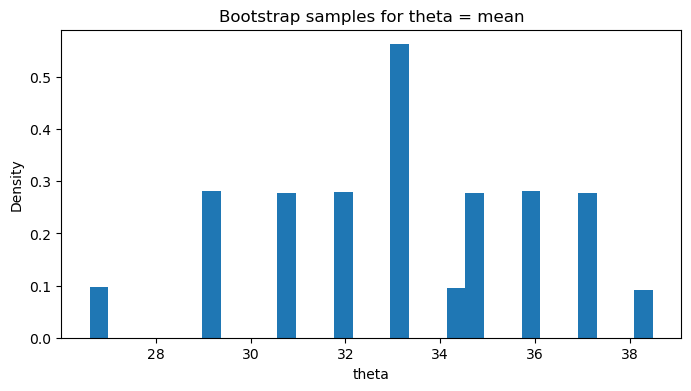

33.166666666666664 33.17327023405697


In [19]:
#Posterior samples for theta = mean
x_obs = np.array([26.6, 38.5, 34.4])
n = len(x_obs)
M = 100000
V = np.random.multinomial(n = n, pvals = np.ones(n)/n, size=M)/n
theta_samples_b = V @ x_obs
plt.figure(figsize=(8, 4))
plt.hist(theta_samples_b, bins=30, density=True)
plt.title("Bootstrap samples for theta = mean")
plt.xlabel("theta")
plt.ylabel("Density")
plt.show()
print(np.mean(x_obs), np.mean(theta_samples))

The classical bootstrap histogram for $\theta$ appears very choppy. This is because of its discrete nature and the fact that we have only 3 observations here. It is also not uniform, and is peaked at the mean of the observed data. 

When $n$ is large, both Bayesian bootstrap and the classical bootstrap will give similar results. 

Back to our favourite problem: 

*Suppose a scientist makes 6 numerical measurements $26.6, 38.5, 34.4, 34, 31, 23.6$ on an unknown real-valued physical quantity $\theta$. On the basis of these measurements, what can be inferred about $\theta$?*

We now use the model: 
\begin{align*}
    X_1, \dots, X_n \mid P \overset{\text{i.i.d}}{\sim} P ~~ \text{ and } ~~ \theta = \text{mean corresponding to} ~ P
\end{align*}
We use discretization and assume that $P$ is supported on a large finite set $G = \{g_1, \dots, g_k\}$ e.g., $G = \{0.1, 0.2, \dots, 99.9, 100.0\}$. Let the probabilities assigned by $P$ to $g_1, \dots, g_k$ be $p_1, \dots, p_k$. We use the noninformative prior: 
\begin{align*}
   (p_1, \dots, p_k) \sim \text{Dirichlet}(0, \dots, 0). 
\end{align*}
This leads to the posterior: 
\begin{align*}
  P \mid X_1 = x_1, \dots, X_n = x_n \sim \sum_{i=1}^n w_i \delta_{\{x_i\}} ~\text{where} ~ (w_1, \dots, w_n) \sim \text{Dirichlet}(1, \dots, 1). 
\end{align*}
The posterior of $\theta$ is therefore: 
\begin{align*}
   \theta \mid \text{data} \sim \sum_{i=1}^n w_i x_i \text{ where } (w_1, \dots, w_n) \sim \text{Dirichlet}(1, \dots, 1). 
\end{align*}
Below we simulate from this posterior, and obtain posterior mean and 95\% credible interval.

In [20]:
x_obs = np.array([26.6, 38.5, 34.4, 34, 31, 23.6])
#x_obs = np.array([26.6, 38.5, 34.4, 34, 31, 23.6, 100]) #this data will reveal differences between estimation of mean and median
n = len(x_obs)
M = 100000 #number of posterior samples
np.random.seed(42) #for reproducibility
W = np.random.dirichlet(alpha = np.ones(n), size=M) #M samples from the Dirichlet distribution
theta_samples = W @ x_obs #compute the posterior samples of theta

theta_mean = np.mean(theta_samples)
theta_ci = np.quantile(theta_samples, [0.025, 0.975])

print(f"Posterior mean (Bayesian Bootstrap) of theta: {theta_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval: [{theta_ci[0]:.2f}, {theta_ci[1]:.2f}]")

Posterior mean (Bayesian Bootstrap) of theta: 31.35
95% credible (Bayesian Bootstrap) interval: [27.53, 34.90]


Below is a histogram of all the posterior samples. 

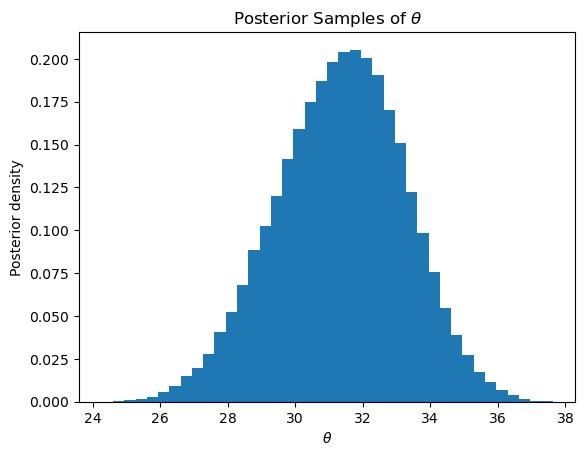

In [21]:
plt.hist(theta_samples, bins=40, density=True)
plt.xlabel(r"$\theta$")
plt.ylabel("Posterior density")
plt.title("Posterior Samples of $\\theta$")
plt.show()

The usual bootstrap generates samples of the form: 
\begin{align*}
   \sum_{i=1}^n v_i \delta_{\{x_i\}} ~~ \text{ where } ~~ (v_1, \dots, v_n) \sim \frac{1}{n}\text{Multinomial}(n; 1/n, \dots, 1/n). 
\end{align*}
This leads to samples of $\theta$ (which is the mean of $P$) generated according to: 
\begin{align*}
   \sum_{i=1}^n v_i x_i ~~ \text{ where } ~~ (v_1, \dots, v_n) \sim \frac{1}{n}\text{Multinomial}(n; 1/n, \dots, 1/n). 
\end{align*}

In [22]:
#Bootstrap samples
V = np.random.multinomial(n=n, pvals=np.ones(n)/n, size=M)/n
theta_bootstrap = V @ x_obs

Below we plot the histograms of the bootstrap and Bayesian bootstrap samples. 

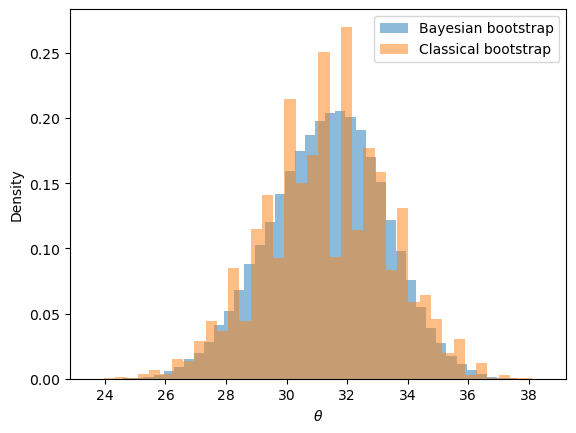

In [23]:
plt.hist(theta_samples, bins=40, density=True, alpha=0.5, label="Bayesian bootstrap")
plt.hist(theta_bootstrap, bins=40, density=True, alpha=0.5, label="Classical bootstrap")
plt.legend()
plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.show()

The two histograms overlap considerably, but the classical bootstrap histogram is much rougher compared to the Bayesian bootstrap histogram. 

Below we compute the bootstrap mean and confidence intervals, and compare them to the Bayesian bootstrap mean and confidence intervals.

In [24]:
theta_mean_bootstrap = np.mean(theta_bootstrap)
theta_ci_bootstrap = np.quantile(theta_bootstrap, [0.025, 0.975])

print(f"Bootstrap mean of theta: {theta_mean_bootstrap:.2f}")
print(f"95% bootstrap confidence interval: [{theta_ci_bootstrap[0]:.2f}, {theta_ci_bootstrap[1]:.2f}]")

print(f"Posterior mean (Bayesian Bootstrap) of theta: {theta_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval: [{theta_ci[0]:.2f}, {theta_ci[1]:.2f}]")

Bootstrap mean of theta: 31.35
95% bootstrap confidence interval: [27.13, 35.15]
Posterior mean (Bayesian Bootstrap) of theta: 31.35
95% credible (Bayesian Bootstrap) interval: [27.53, 34.90]


Note that these intervals are very close to each other but the Bayesian bootstrap interval is slightly narrower. It can be checked that: 
\begin{align*}
   \mathbb{E} \left(\theta \mid \text{data} \right) = \mathbb{E} \left(\sum_{i=1}^n w_i x_i \mid \text{data} \right) = \bar{x} ~~ \text{ and } ~~ \text{var} \left(\theta \mid \text{data}  \right) = \text{var} \left(\sum_{i=1}^n w_i x_i \mid \text{data}  \right) = \frac{1}{n(n+1)} \sum_{i=1}^n (x_i - \bar{x})^2. 
\end{align*}
and
\begin{align*}
   \mathbb{E} \left(\sum_{i=1}^n v_i x_i \mid \text{data} \right) = \bar{x} ~~ \text{ and } ~~ \text{var} \left(\sum_{i=1}^n v_i x_i \mid \text{data} \right) = \frac{1}{n} \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2
\end{align*}
So the Bayesian bootstrap variance is very slightly (by a factor of $n/(n+1)$) smaller than the bootstrap variance. 


### Median Estimation

Instead of assuming that $\theta$ is the mean of $P$, we can assume that $\theta$ is the median of $P$. We would then be computing the medians of the generated samples (either the Bayesian bootstrap samples, or the usual bootstrap samples).

For an arbitrary probability measure $Q$, we define its median as: 
\begin{align*}
   \inf \left\{x: Q(-\infty, x] \geq 0.5 \right\} 
\end{align*}
This definition makes sense even when $Q$ is discrete. As an example, note that if $Q$ is the discrete distribution taking the two values 0 and 1 with equal probabilities, then the median of $Q$ according to the above definition is 0. 

Below we compute the medians corresponding to each Bayesian boostrap sample. 

In [25]:
order_obs = np.argsort(x_obs)
x_sorted = x_obs[order_obs]
W_sorted = W[:, order_obs]
cdf = np.cumsum(W_sorted, axis=1)
median_idx = np.argmax(cdf >= 0.5, axis=1)
theta_median_samples = x_sorted[median_idx]

In [26]:
theta_median_mean = np.mean(theta_median_samples)
theta_median_ci = np.quantile(theta_median_samples, [0.025, 0.975])

print(f"Posterior mean (Bayesian Bootstrap) of theta (median): {theta_median_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval for theta (median): [{theta_median_ci[0]:.2f}, {theta_median_ci[1]:.2f}]")

#Compare to mean: 
print(f"Posterior mean (Bayesian Bootstrap) of theta (mean): {theta_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval for theta (mean): [{theta_ci[0]:.2f}, {theta_ci[1]:.2f}]")

Posterior mean (Bayesian Bootstrap) of theta (median): 31.78
95% credible (Bayesian Bootstrap) interval for theta (median): [23.60, 38.50]
Posterior mean (Bayesian Bootstrap) of theta (mean): 31.35
95% credible (Bayesian Bootstrap) interval for theta (mean): [27.53, 34.90]


Next we do the same thing for the usual bootstrap. 

In [27]:
order_obs = np.argsort(x_obs)
x_sorted = x_obs[order_obs]
V_sorted = V[:, order_obs]
cdf = np.cumsum(V_sorted, axis=1)
median_idx = np.argmax(cdf >= 0.5, axis=1)
theta_median_bootstrap = x_sorted[median_idx]

In [28]:
theta_median_bootstrap_mean = np.mean(theta_median_bootstrap)
theta_median_bootstrap_ci = np.quantile(theta_median_bootstrap, [0.025, 0.975])

print(f"Posterior mean (Bootstrap) of theta (median): {theta_median_bootstrap_mean:.2f}")
print(f"95% credible (Bootstrap) interval for theta (median): [{theta_median_bootstrap_ci[0]:.2f}, {theta_median_bootstrap_ci[1]:.2f}]")

#Compare to mean: 
print(f"Posterior mean (Bootstrap) of theta (mean): {theta_mean_bootstrap:.2f}")
print(f"95% credible (Bootstrap) interval for theta (mean): [{theta_ci_bootstrap[0]:.2f}, {theta_ci_bootstrap[1]:.2f}]")

Posterior mean (Bootstrap) of theta (median): 30.51
95% credible (Bootstrap) interval for theta (median): [23.60, 34.40]
Posterior mean (Bootstrap) of theta (mean): 31.35
95% credible (Bootstrap) interval for theta (mean): [27.13, 35.15]


The histograms of the two median samples (Bootstrap and Bayesian Bootstrap) are plotted below. 

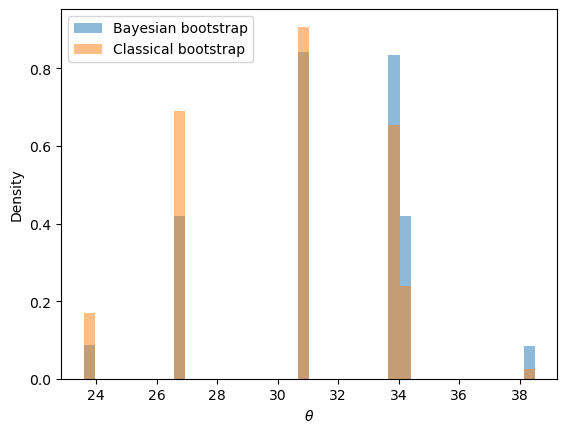

In [29]:
plt.hist(theta_median_samples, bins=40, density=True, alpha=0.5, label="Bayesian bootstrap")
plt.hist(theta_median_bootstrap, bins=40, density=True, alpha=0.5, label="Classical bootstrap")
plt.legend()
plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.show()

For more on the Bayesian bootstrap and its connection to the classical bootstrap, I highly recommend the blog post https://www.sumsar.net/blog/2015/04/the-non-parametric-bootstrap-as-a-bayesian-model/ and the original paper on the Bayesian Bootstrap by Donald Rubin (1981). 

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, digamma
from collections import Counter

# Text Example

In [31]:
tokens = """
the cat sat on the mat . the cat ate the fish . the dog sat on the mat .
the dog chased the cat . the cat ran from the dog . you see the cat .
you see the dog . you see the mat . i see the cat . i see the dog .
the cat sat on the fish . the dog ate the fish . you see the fish .
""".split()

In [32]:
vocab = sorted(set(tokens))
w2i = {w: idx for idx, w in enumerate(vocab)}
i2w = {idx: w for w, idx in w2i.items()}
k = len(vocab)
n = len(tokens)
print(f"Tokens n = {n},  Vocabulary size k = {k}\n")
print("Vocabulary:", vocab)
print("tokens:", tokens)

Tokens n = 76,  Vocabulary size k = 15

Vocabulary: ['.', 'ate', 'cat', 'chased', 'dog', 'fish', 'from', 'i', 'mat', 'on', 'ran', 'sat', 'see', 'the', 'you']
tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat', '.', 'the', 'cat', 'ate', 'the', 'fish', '.', 'the', 'dog', 'sat', 'on', 'the', 'mat', '.', 'the', 'dog', 'chased', 'the', 'cat', '.', 'the', 'cat', 'ran', 'from', 'the', 'dog', '.', 'you', 'see', 'the', 'cat', '.', 'you', 'see', 'the', 'dog', '.', 'you', 'see', 'the', 'mat', '.', 'i', 'see', 'the', 'cat', '.', 'i', 'see', 'the', 'dog', '.', 'the', 'cat', 'sat', 'on', 'the', 'fish', '.', 'the', 'dog', 'ate', 'the', 'fish', '.', 'you', 'see', 'the', 'fish', '.']


## i.i.d Model

The observed counts for each of the $k$ words are given below. 

In [33]:
counts = Counter(tokens)
print("Word counts:")
for w in vocab:
    print(f"  {w:>8s}: {counts[w]}")

Word counts:
         .: 13
       ate: 2
       cat: 7
    chased: 1
       dog: 6
      fish: 4
      from: 1
         i: 2
       mat: 3
        on: 3
       ran: 1
       sat: 3
       see: 6
       the: 20
       you: 4


We can use the Dirichlet-Multinomial inference here with prior Dirichlet $(0, \dots, 0)$. This leads to the posterior Dirichlet $(x_1, \dots, x_k)$ where $x_i$ is the observed count for the $i$-th word. We can use this fitted model to do sentence generation. We first draw $(p_1, \dots, p_k)$ from Dirichlet $(x_1, \dots, x_k)$ and then draw words from sequentially from Multinomial $(1; p_1, \dots, p_k)$ until we get a '.' (period). 

In [34]:
np.random.seed(42)
# Dirichlet posterior parameters
alpha = np.array([counts[w] for w in vocab], dtype=float)
print("Generating sentences from the i.i.d model posterior posterior:\n")
M = 20 #this is the number of sentences
for s in range(M):
    # Step 1: Draw a probability vector from the Dirichlet posterior
    p = np.random.dirichlet(alpha)    
    # Step 2: Generate words until '.'
    sentence = []
    while True:
        word_idx = np.random.choice(k, p=p)
        word = i2w[word_idx]
        sentence.append(word)
        if word == '.':
            break
    print(f"  Sentence {s+1}: {' '.join(sentence)}")

Generating sentences from the i.i.d model posterior posterior:

  Sentence 1: .
  Sentence 2: the .
  Sentence 3: .
  Sentence 4: mat cat .
  Sentence 5: dog the the sat .
  Sentence 6: the ran cat cat see the the the ran .
  Sentence 7: the chased .
  Sentence 8: the dog dog the the the the on mat the the the the the dog fish .
  Sentence 9: .
  Sentence 10: sat see .
  Sentence 11: the see the cat .
  Sentence 12: chased the the the the .
  Sentence 13: from the .
  Sentence 14: .
  Sentence 15: the i i cat .
  Sentence 16: ate .
  Sentence 17: fish sat .
  Sentence 18: cat the the mat mat .
  Sentence 19: cat .
  Sentence 20: sat chased sat ate i mat .


These sentences are of course not realistic, which means that our model is too silly and unrealistic for this dataset. Note that this model works directly with the individual word counts but ignores any information about how words occur in specific sequences. A slighly improved model can be obtained by working with bigram counts as opposed to individual word counts. 

## AR(1) model (also known as the Markov or Bigram model)

This model uses bigram counts (and not the raw data directly). Below we compute the bigram counts $x_{j \mid i}$ as well as $x_i = \sum_{j=1}^k x_{j \mid i}$. 

In [35]:
# --- 2. Bigram counts: X[j, i] = x_{j|i} = # times word j follows word i ---
X = np.zeros((k, k), dtype=np.int64)
for t in range(1, n):
    i_prev = w2i[tokens[t - 1]]  # i = previous word
    j_next = w2i[tokens[t]]      # j = next word
    X[j_next, i_prev] += 1

# x_i = sum_j x_{j|i}  (times i appears as the previous word)
x_prev = X.sum(axis=0)  # shape (k,)

print(X)
print(x_prev)

[[0 0 3 0 3 4 0 0 3 0 0 0 0 0 0]
 [0 0 1 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 7 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 6 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 4 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [2 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 3 0]
 [0 0 0 0 0 0 0 0 0 0 0 3 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 2 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 2 0 0 0 0 0 0 4]
 [6 2 0 1 0 0 1 0 0 3 0 0 6 0 0]
 [4 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
[12  2  7  1  6  4  1  2  3  3  1  3  6 20  4]


The first column refers to the number of times each word appears after '.'. More specifically, after '.', 'i' appears 2 times, 'the' appears 6 times and 'you' appears 4 times. And the sum of these numbers is the number of times '.' appears as the previous word. 

The next function calculates the log-Evidence for given values of $a_1, \dots, a_k$. Note that Evidence is the probability of obtaining the bigram sequence given values of $a_1, \dots, a_k$. 

In [36]:
# --- 3. Log marginal likelihood (evidence) up to constants in a ---
# Here we parameterize a = (a_1,...,a_k) and A = sum_j a_j.
# The marginal over all rows i is:
#   prod_i [ Γ(A)/Γ(x_i + A) * prod_j Γ(x_{j|i}+a_j)/Γ(a_j) ]
# (multinomial coefficients omitted since they do not depend on a)

def log_evidence(a):
    A = a.sum()
    val = 0.0
    for i in range(k):
        if x_prev[i] == 0:
            continue
        val += gammaln(A) - gammaln(x_prev[i] + A)
        val += (gammaln(X[:, i] + a) - gammaln(a)).sum()
    return val

The next function calculates the gradient of the log-evidence using the digamma function (which is in-built in scipy, and is the derivative of the logarithm of the Gamma function). The notes has the exact formula for the gradient in terms of the digamma function. 

In [37]:
def grad_log_evidence(a):
    A = a.sum()
    g = np.zeros(k)
    for i in range(k):
        if x_prev[i] == 0:
            continue
        # vector part: sum_i [ ψ(x_{j|i}+a_j) - ψ(a_j) ]
        g += digamma(X[:, i] + a) - digamma(a)
        # scalar part from A: sum_i [ ψ(A) - ψ(x_i + A) ] added to every component
        g += digamma(A) - digamma(x_prev[i] + A)
    return g


The code below maximizes the log-Evidence with respect to $a_1, \dots, a_k$. It uses a simple gradient ascent method. It calculates the gradient of the log-Evidence at the current value of $a = (a_1, \dots, a_k)$ and takes a step in that direction. A line search is done in that direction to find the best step-size. 

In [38]:
a = 1 * np.ones(k) #initial values of a_1, \dots, a_k

print("Optimizing hyperparameters a = (a_1,...,a_k)...")
for it in range(3000):
    log_a = np.log(a)
    le = log_evidence(a)
    g = grad_log_evidence(a) * a  # chain rule: d/d(log a) = a * d/da
    step = 0.01
    for _ in range(10):
        trial = np.exp(log_a + step * g).clip(1e-10)
        if log_evidence(trial) > le:
            break
        step *= 0.5
    a = np.exp(log_a + step * g).clip(1e-10)
    if it % 100 == 0 or it == 299:
        print(f"  iter {it:3d}: log_ev = {le:.2f}, A = {a.sum():.3f}")

A = a.sum()


Optimizing hyperparameters a = (a_1,...,a_k)...
  iter   0: log_ev = -165.87, A = 14.829
  iter 100: log_ev = -140.73, A = 7.111
  iter 200: log_ev = -132.25, A = 3.348
  iter 299: log_ev = -128.35, A = 2.041
  iter 300: log_ev = -128.33, A = 2.033
  iter 400: log_ev = -126.79, A = 1.500
  iter 500: log_ev = -126.19, A = 1.247
  iter 600: log_ev = -125.95, A = 1.111
  iter 700: log_ev = -125.85, A = 1.034
  iter 800: log_ev = -125.81, A = 0.987
  iter 900: log_ev = -125.80, A = 0.958
  iter 1000: log_ev = -125.79, A = 0.940
  iter 1100: log_ev = -125.79, A = 0.928
  iter 1200: log_ev = -125.79, A = 0.920
  iter 1300: log_ev = -125.79, A = 0.915
  iter 1400: log_ev = -125.79, A = 0.912
  iter 1500: log_ev = -125.79, A = 0.910
  iter 1600: log_ev = -125.79, A = 0.909
  iter 1700: log_ev = -125.79, A = 0.908
  iter 1800: log_ev = -125.79, A = 0.907
  iter 1900: log_ev = -125.79, A = 0.907
  iter 2000: log_ev = -125.79, A = 0.907
  iter 2100: log_ev = -125.79, A = 0.906
  iter 2200: log_ev

Below are the values of the estimated $a_1, \dots, a_k$ (and their sum $A = a_1 + \dots + a_k$). 

In [39]:
print(f"\nOptimal A = {A:.3f}\n")
print(f"{'word':>8s}  {'a_j':>10s}")
print("-" * 30)
for j in range(k):
    print(f"{vocab[j]:>8s}  {a[j]:10.4f}")


Optimal A = 0.906

    word         a_j
------------------------------
       .      0.1523
     ate      0.0627
     cat      0.0339
  chased      0.0313
     dog      0.0337
    fish      0.0332
    from      0.0313
       i      0.0323
     mat      0.0328
      on      0.0328
     ran      0.0313
     sat      0.0646
     see      0.0684
     the      0.2321
     you      0.0332


Having obtained $a_1, \dots, a_k$, we compute below the posterior mean estimates of $p_{j \mid i}$. 

In [40]:
P_hat = np.zeros((k, k))
for i in range(k):
    P_hat[:, i] = (X[:, i] + a) / (x_prev[i] + A)
print(P_hat)

[[0.01179979 0.05240418 0.39871914 0.07989796 0.45645401 0.84636298
  0.07989796 0.05240418 0.80702976 0.03898798 0.07989796 0.03898798
  0.0220515  0.00728443 0.03104104]
 [0.0048559  0.02156559 0.13441252 0.03287995 0.15387557 0.01277414
  0.03287995 0.02156559 0.0160445  0.0160445  0.03287995 0.0160445
  0.00907473 0.00299772 0.01277414]
 [0.00262547 0.01166    0.00428589 0.0177774  0.00490649 0.00690667
  0.0177774  0.01166    0.00867488 0.00867488 0.0177774  0.00867488
  0.00490649 0.3364523  0.00690667]
 [0.00242796 0.01078282 0.00396346 0.01644002 0.14933821 0.00638709
  0.01644002 0.01078282 0.00802227 0.00802227 0.01644002 0.00802227
  0.00453738 0.00149886 0.00638709]
 [0.00261083 0.01159499 0.00426199 0.01767828 0.00487913 0.00686816
  0.01767828 0.01159499 0.00862651 0.00862651 0.01767828 0.00862651
  0.00487913 0.28861019 0.00686816]
 [0.00257218 0.01142334 0.0041989  0.01741658 0.0048069  0.00676649
  0.01741658 0.01142334 0.00849881 0.00849881 0.01741658 0.00849881
  0.0

In [41]:
print(f"\n{'='*45}")
print("NEXT-WORD PREDICTIONS (posterior mean)")
print(f"{'='*45}")

#The following code predicts the top five most probable next words for a given word
def predict_next(prev_word, top_k=5):
    i = w2i[prev_word]
    probs = P_hat[:, i]                 # probs over j given i
    ranked = np.argsort(probs)[::-1]
    return [(i2w[j], probs[j]) for j in ranked[:top_k]]


for ctx in ['the', 'cat', 'you', 'dog', '.', 'on']:
    i = w2i[ctx]
    lam = A / (x_prev[i] + A)  # shrinkage weight on the prior mean m
    print(f"\nAfter '{ctx}'  (x_i={int(x_prev[i])}, λ={lam:.3f}):")
    for word, prob in predict_next(ctx, top_k=5):
        bar = '█' * int(prob * 40)
        print(f"  {word:>8s}  {prob:.3f}  {bar}")



NEXT-WORD PREDICTIONS (posterior mean)

After 'the'  (x_i=20, λ=0.043):
       cat  0.336  █████████████
       dog  0.289  ███████████
      fish  0.193  ███████
       mat  0.145  █████
       the  0.011  

After 'cat'  (x_i=7, λ=0.115):
         .  0.399  ███████████████
       sat  0.261  ██████████
       ate  0.134  █████
       ran  0.130  █████
       the  0.029  █

After 'you'  (x_i=4, λ=0.185):
       see  0.829  █████████████████████████████████
       the  0.047  █
         .  0.031  █
       sat  0.013  
       ate  0.013  

After 'dog'  (x_i=6, λ=0.131):
         .  0.456  ██████████████████
       sat  0.154  ██████
       ate  0.154  ██████
    chased  0.149  █████
       the  0.034  █

After '.'  (x_i=12, λ=0.070):
       the  0.483  ███████████████████
       you  0.313  ████████████
         i  0.157  ██████
         .  0.012  
       see  0.005  

After 'on'  (x_i=3, λ=0.232):
       the  0.827  █████████████████████████████████
         .  0.039  █
       see  0.0

The code below generates sentences using this model. It takes as input a starting word (e.g., '.') and then starts generating from there until the period '.' appears. Sentence generation can be done in two different ways here. The first way uses the Bayesian estimates of $p_{j \mid i}$ and generates words from multinomials. The second way also generates $p_{j \mid i}$ from their posterior first before generating from multinomials. 

In [42]:
def generate(start_word, length=12, seed=45):
    rng = np.random.default_rng(seed)
    words = [start_word]
    for _ in range(length):
        i = w2i[words[-1]]
        j = rng.choice(k, p=P_hat[:, i])
        words.append(i2w[j])
        if words[-1] == '.':
            break
    return ' '.join(words)

print(f"\n{'='*45}")
print("GENERATED SENTENCES")
print(f"{'='*45}\n")
for s in range(20):
    print("  " + generate('.', seed=45 + s))


GENERATED SENTENCES

  . the dog chased the dog i see the dog chased the mat
  . you i see the mat .
  . you see the cat the cat .
  . the dog ate the fish cat ran from the cat .
  . the dog .
  . you see the mat .
  . you see the cat sat on the fish .
  . the dog ate .
  . .
  . the dog .
  . you see the cat ate the fish the cat ate the dog
  . you .
  . the dog sat on the cat ate the cat .
  . the mat .
  . the fish .
  . the cat .
  . the fish .
  . the fish .
  . the the cat ate see the dog .
  . you see on the mat .


You can ignore the starting period while interpreting each of these sentences. 

In the above, we fixed the Bayesian estimate of $P[i, j]$ while generating the sentences. We can also draw $P$ from the correct Bayesian posterior, before generating each sentence. This is done below.



In [43]:
def sample_P_posterior(rng):
    """
    Sample a full transition matrix P from the posterior.
    Each column i is p_{·|i} ~ Dirichlet(X[:, i] + a).
    """
    P = np.zeros((k, k))
    for i in range(k):
        alpha = X[:, i] + a
        P[:, i] = rng.dirichlet(alpha)
    return P

def generate_from_P(start_word, P, length=12, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    words = [start_word]
    for _ in range(length):
        i = w2i[words[-1]]
        j = rng.choice(k, p=P[:, i])
        words.append(i2w[j])
        if words[-1] == '.':
            break
    return ' '.join(words)

def generate_posterior_sampled(start_word, length=12, seed=45):
    """
    For THIS sentence: sample P ~ posterior, then generate using that P.
    """
    rng = np.random.default_rng(seed)
    P = sample_P_posterior(rng)
    return generate_from_P(start_word, P, length=length, rng=rng)

# --- 9. Generate sentences ---
print(f"\n{'='*45}")
print("GENERATED SENTENCES (posterior-sampled P per sentence)")
print(f"{'='*45}\n")
for s in range(20):
    print(" " + generate_posterior_sampled('.', seed=45 + s))


GENERATED SENTENCES (posterior-sampled P per sentence)

 . the cat .
 . the cat see the dog .
 . i see the mat .
 . the cat .
 . the fish .
 . you see the mat .
 . the cat sat fish .
 . you see the fish .
 . the dog .
 . the cat sat on dog .
 . the cat .
 . the mat .
 . the fish .
 . you see the dog .
 . the mat .
 . you see the cat .
 . on the cat sat on the dog cat .
 . i see the fish .
 . you see the see the fish .
 . the dog .


Overall these sentences are more realistic compared to the simple i.i.d (bag of words) model. Obviously, more sophisticated language models will  yield much more realistic sentences. 